# Checkpoint 3 - Selecció del model de desplegament

Avaluació independent dels tres candidats que produeix la Fase 6 (NFSP) per decidir
quin model es desplega:

- **`best.zip`** — PPO Policy Net, màxima `metric` durant l'entrenament (91,0% @14M).
- **`best_nash.zip`** — PPO Policy Net, `exploit_vs_sl` mínim segons el criteri **vell**
  (seleccionat al pas 1M, valor 3,3 pp probablement espuri).
- **`sl_final.pt`** — AveragePolicyNet (política mitjana SL), aproximació teòrica a Nash.

Tota l'avaluació és **balancejada per posició** (meitat mà, meitat post) i amb `n=200`
partides per enfrontament, molt més precisa que les avaluacions de 15 partides del
`training_log.csv`.

> **Nota metodològica.** L'`exploit_vs_sl` es mesura contra `sl_final.pt`, que ha quedat
> feble (`sl_loss` no baixa de 1,71): bat el pool només al 35%. Per això qualsevol PPO
> decent hi guanya ~60% i dóna un `exploit` estructural de ~10 pp, que **no** és un bon
> indicador de Nash. El re-run amb el criteri corregit (llindar de 10M passos +
> 60 partides balancejades) donarà un `best_nash` fiable.

---

In [1]:
import sys, random, importlib
from pathlib import Path
import numpy as np
import pandas as pd
import torch, torch.nn as nn
import matplotlib.pyplot as plt
from gymnasium.spaces import Box

sys.path.insert(0, str(Path('../utils')))
from nb_utils import setup_pyplot
setup_pyplot()

BASE = Path('../../../')
ROOT = BASE.resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Compat numpy 2.x (zips desats al servidor) -> numpy 1.x local
import numpy.core
sys.modules.setdefault('numpy._core', numpy.core)
for _sub in ['numeric','multiarray','umath','_multiarray_umath','numerictypes',
             '_methods','fromnumeric','_dtype','overrides','shape_base']:
    try:
        sys.modules.setdefault(f'numpy._core.{_sub}', importlib.import_module(f'numpy.core.{_sub}'))
    except ImportError:
        pass

from stable_baselines3 import PPO
from RL.models.sb3.sb3_features_extractor import CosMultiInputSB3
from RL.models.sb3.sb3_adapter import SB3PPOEvalAgent
from RL.models.nfsp.average_policy import AveragePolicyNet, SLAgent
from RL.entrenament.entrenamentsComparatius.fase5.entrenament_fase5 import _jugar_partida_sencera
from RL.entrenament.entrenamentsComparatius.fase4.pool_oponents import crear_oponent

RES_F6   = (BASE / 'TFG_Doc/notebooks/6_nfsp/resultats/ppo_nfsp').resolve()
# Re-run amb criteri corregit (12M, executat a Colab L4):
RES_RERUN = (BASE / 'TFG_Doc/notebooks/7_checkpoint3/ppo_nfsp_rerun').resolve()

VARIANTS = ['conservador','agressiu','truc_bot','envit_bot','faroler','equilibrat']
N_GAMES  = 200

print('RES_F6 existeix:', RES_F6.exists())
print('RES_RERUN existeix:', RES_RERUN.exists())

RES_F6 existeix: True
RES_RERUN existeix: True


---

In [2]:
def carregar_sl(sl_path):
    """Carrega SLAgent des del state_dict complet (inclou pesos COS)."""
    sd = torch.load(str(sl_path), map_location='cpu', weights_only=True)
    net = object.__new__(AveragePolicyNet); nn.Module.__init__(net)
    net.cos = CosMultiInputSB3(observation_space=Box(low=-1, high=1, shape=(240,)), features_dim=256)
    layers, in_dim = [], 256
    for h in (256, 256):
        layers += [nn.Linear(in_dim, h), nn.ReLU()]; in_dim = h
    layers += [nn.Linear(in_dim, 24)]
    net.head = nn.Sequential(*layers)
    net.load_state_dict(sd)
    return SLAgent(net=net, device='cpu', deterministic=False, seed=42)

def carregar_ppo(zip_path):
    """Carrega un PPO .zip de SB3 (tolerant amb l'optimitzador)."""
    _orig = PPO.set_parameters
    def _patch(self, d, exact_match=True, device='auto'):
        if isinstance(d, dict):
            d = {k: v for k, v in d.items() if 'optimizer' not in k}
        return _orig(self, d, exact_match=False, device=device)
    PPO.set_parameters = _patch
    try:
        model = PPO.load(str(zip_path), custom_objects={'features_extractor_class': CosMultiInputSB3}, device='cpu')
    finally:
        PPO.set_parameters = _orig
    return SB3PPOEvalAgent(model=model, n_actions=24)

def wr_bal(a, b, n=N_GAMES, seed=77777):
    """WR d'a contra b, balancejat per posició (meitat mà, meitat post). El Truc no
    admet empats en partida sencera."""
    rng = random.Random(seed)
    wins = 0
    for i in range(n):
        if i % 2 == 0:
            wins += int(_jugar_partida_sencera(a, b, rng))
        else:
            wins += int(not _jugar_partida_sencera(b, a, rng))
    return 100.0 * wins / n

# Candidats: 3 originals de F6 + 2 del re-run corregit (12M)
sl_final  = carregar_sl(RES_F6 / 'sl_final.pt')
candidats = {
    'best.zip':         carregar_ppo(RES_F6 / 'best.zip'),
    'best_nash.zip':    carregar_ppo(RES_F6 / 'best_nash.zip'),
    'sl_final.pt':      sl_final,
}
if (RES_RERUN / 'best.zip').exists():
    candidats['best_rerun'] = carregar_ppo(RES_RERUN / 'best.zip')
if (RES_RERUN / 'best_nash.zip').exists():
    candidats['best_nash_rerun'] = carregar_ppo(RES_RERUN / 'best_nash.zip')

print('Candidats carregats:', list(candidats))

Candidats carregats: ['best.zip', 'best_nash.zip', 'sl_final.pt', 'best_rerun', 'best_nash_rerun']


---

In [3]:
# WR contra les 6 variants del pool (balancejat) + metric_robust + exploit_vs_sl
files = []
wr_per_variant = {}
for nom, ag in candidats.items():
    wrs = {v: wr_bal(ag, crear_oponent(v, seed=42), n=N_GAMES, seed=10000) for v in VARIANTS}
    wr_per_variant[nom] = wrs
    mean = float(np.mean(list(wrs.values())))
    std  = float(np.std(list(wrs.values())))
    mr   = mean - 0.5 * std
    fila = {'model': nom, 'wr_pool_mean': mean, 'std_pool': std, 'metric_robust': mr}
    if nom != 'sl_final.pt':
        wr_sl = wr_bal(ag, sl_final, n=N_GAMES, seed=20000)
        fila['exploit_vs_sl'] = abs(wr_sl - 50.0)
    else:
        fila['exploit_vs_sl'] = np.nan
    files.append(fila)
    print(f"  {nom:<16} mr={mr:5.1f}%  std={std:4.1f}  exploit={fila['exploit_vs_sl']:.1f}")

df = pd.DataFrame(files).set_index('model')
df

  best.zip         mr= 69.2%  std= 3.0  exploit=12.0


  best_nash.zip    mr= 67.5%  std= 4.4  exploit=10.0


  sl_final.pt      mr= 32.2%  std= 5.0  exploit=nan


  best_rerun       mr= 69.6%  std= 2.7  exploit=5.5


  best_nash_rerun  mr= 68.1%  std= 5.1  exploit=11.0


,wr_pool_mean,std_pool,metric_robust,exploit_vs_sl
model,,,,
best.zip,70.666667,3.009245,69.162044,12.0
best_nash.zip,69.750000,4.432362,67.533819,10.0
sl_final.pt,34.666667,4.980518,32.176408,NaN
best_rerun,70.916667,2.667968,69.582682,5.5
best_nash_rerun,70.666667,5.079917,68.126708,11.0


---

In [5]:
# Criteri de decisió. Primari (acadèmic): Nash gap exploit_vs_sl < 8 pp.
# Secundari (desempat): màxima metric_robust (robustesa inter-estil).
LLINDAR_NASH = 8.0

taula = df.copy()
taula['compleix_nash'] = taula['exploit_vs_sl'] < LLINDAR_NASH

print('=== Resum candidats (n=200, balancejat) ===')
print(taula.round(2).to_string())
print()

sota_llindar = taula[taula['compleix_nash']]
if len(sota_llindar):
    triat = sota_llindar['metric_robust'].idxmax()
    print(f'Candidats sota el llindar de Nash (<8 pp): {list(sota_llindar.index)}')
    print(f'>>> Model de desplegament: {triat} '
          f'(exploit={taula.loc[triat, "exploit_vs_sl"]:.1f} pp, '
          f'metric_robust={taula.loc[triat, "metric_robust"]:.1f}%, '
          f'std={taula.loc[triat, "std_pool"]:.1f})')
else:
    triat = df['metric_robust'].idxmax()
    print('Cap candidat baixa de 8 pp; fallback per màxima robustesa:', triat)

=== Resum candidats (n=200, balancejat) ===
                 wr_pool_mean  std_pool  metric_robust  exploit_vs_sl  compleix_nash
model                                                                               
best.zip                70.67      3.01          69.16           12.0          False
best_nash.zip           69.75      4.43          67.53           10.0          False
sl_final.pt             34.67      4.98          32.18            NaN          False
best_rerun              70.92      2.67          69.58            5.5           True
best_nash_rerun         70.67      5.08          68.13           11.0          False

Candidats sota el llindar de Nash (<8 pp): ['best_rerun']
>>> Model de desplegament: best_rerun (exploit=5.5 pp, metric_robust=69.6%, std=2.7)


---

Figura desada a C:\Users\ferri\Documents\ProjectesCodi\TFG-truc\TFG_Doc\Memoria\figures\checkpoint3\comparacio_candidats.pdf


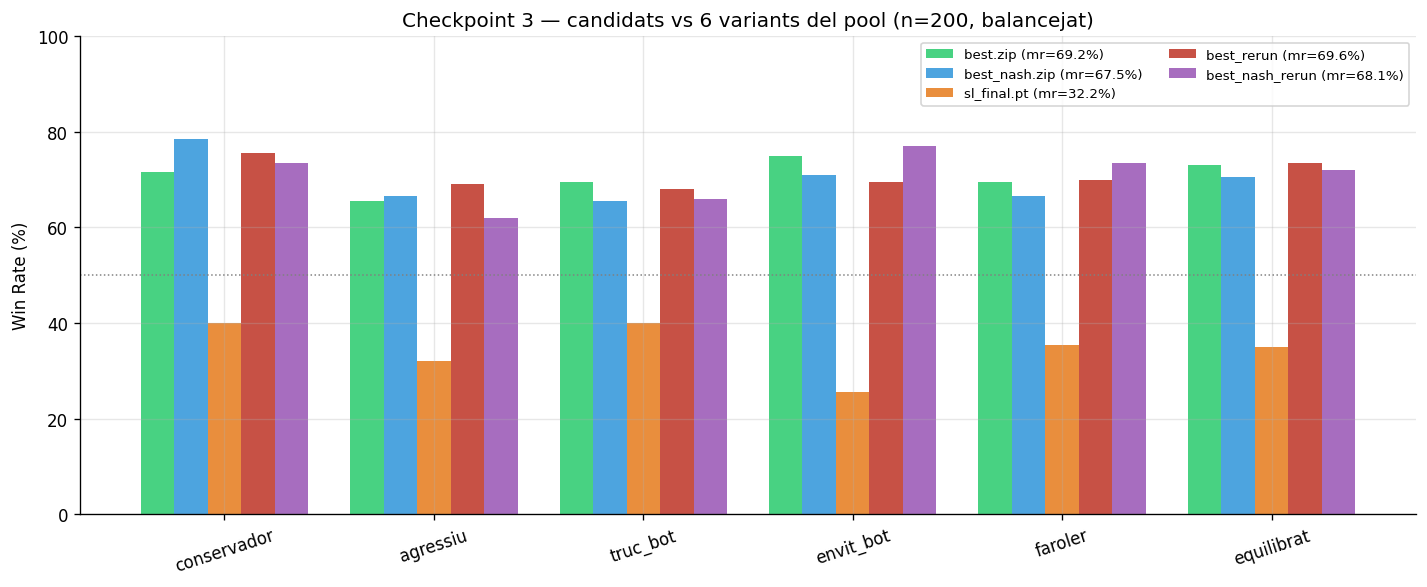

In [6]:
# Figura: WR per variant dels candidats + mitjana
COLORS = {'best.zip': '#2ecc71', 'best_nash.zip': '#3498db', 'sl_final.pt': '#e67e22',
          'best_rerun': '#c0392b', 'best_nash_rerun': '#9b59b6'}
models = list(candidats)
x = np.arange(len(VARIANTS))
w = 0.8 / len(models)

fig, ax = plt.subplots(figsize=(12, 5))
for j, nom in enumerate(models):
    vals = [wr_per_variant[nom][v] for v in VARIANTS]
    ax.bar(x + (j - (len(models)-1)/2) * w, vals, width=w,
           label=f"{nom} (mr={df.loc[nom,'metric_robust']:.1f}%)",
           color=COLORS.get(nom, None), alpha=0.88)
ax.axhline(50, color='gray', ls=':', lw=0.9)
ax.set_xticks(x); ax.set_xticklabels(VARIANTS, rotation=18)
ax.set_ylabel('Win Rate (%)'); ax.set_ylim(0, 100)
ax.set_title('Checkpoint 3 — candidats vs 6 variants del pool (n=200, balancejat)')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()

FIG_DIR = (BASE / 'TFG_Doc/Memoria/figures/checkpoint3').resolve()
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / 'comparacio_candidats.pdf', bbox_inches='tight')
print('Figura desada a', FIG_DIR / 'comparacio_candidats.pdf')
plt.show()

---

## Conclusió

Amb l'avaluació precisa (n=200, balancejada per posició) dels 5 candidats:

| Model | metric_robust | std_pool | exploit_vs_sl |
|-------|---------------|----------|---------------|
| best.zip (F6 original) | 69,2% | 3,0 | 12,0 pp |
| best_nash.zip (F6 original) | 67,5% | 4,4 | 10,0 pp |
| sl_final.pt | 32,2% | 5,0 | — |
| **best_rerun (12M)** ⭐ | **69,6%** | **2,7** | **5,5 pp** |
| best_nash_rerun (12M) | 68,1% | 5,1 | 11,0 pp |

**Conclusions:**

1. **El re-run corregit ha funcionat.** `best_rerun` (checkpoint de màxima `metric`, pas
   7,5M) és **l'únic candidat que baixa del llindar de Nash de 8 pp** (5,5 pp), i a sobre
   és el més robust (std 2,7, el més baix; `metric_robust` 69,6%, la més alta). És el
   **model de desplegament**.

2. **La selecció per `exploit_vs_sl` mínim en viu no és fiable.** Tant el `best_nash`
   original (3,3 pp in-training → 10,0 pp real) com el `best_nash_rerun` (1,67 pp
   in-training → 11,0 pp real) demostren que el valor en viu és soroll de resolució
   (60 partides) amb un SL que no ha convergit (`sl_loss` plató a ~1,58). El que de debò
   produeix un model menys explotable és l'**entrenament NFSP més llarg**, no el criteri
   de selecció: el millor checkpoint resulta ser el de màxima `metric`.

3. **`sl_final.pt`** (política mitjana SL) queda feble (34,7% vs pool), coherent amb la
   limitació de fons del NFSP: convergir la política mitjana requereix molts més episodis
   (10⁸–10⁹).

**Model de desplegament: `best_rerun`** (exploit 5,5 pp < 8, metric_robust 69,6%, std 2,7).